Assignment 2

In [19]:
options(warn = -1)

In [20]:
Sys.setenv(TZ = "UTC")

In [21]:
library(fpp3)

get_my_data <- function(student_id) {
  set.seed(student_id)
  all_data <- readr::read_rds("https://bit.ly/monashretaildata")
  while(TRUE) {
    retail <- filter(all_data, `Series ID` == sample(`Series ID`, 1))
    if(!any(is.na(fill_gaps(retail)$Turnover))) return(retail)
  }
}

retail <- get_my_data(2211769)

1. Using a test set of 2019--2022, fit an ETS model chosen automatically, and three benchmark methods to the training data. Which gives the best forecasts on the test set, based on RMSE?

In [22]:
retail <- retail %>% as_tsibble(index = Month)

train <- retail %>% filter_index(. ~ "2018-12")
test  <- retail %>% filter_index("2019-01" ~ "2022-12")

fit <- suppressWarnings(
  train %>% model(
    ETS    = ETS(Turnover),
    Mean   = MEAN(Turnover),
    Naive  = NAIVE(Turnover),
    SNaive = SNAIVE(Turnover)
  )
)

fc <- fit %>% forecast(h = nrow(test))

acc_tbl <- fc %>%
  accuracy(test) %>%
  select(.model, RMSE, MAE, MAPE, MASE) %>%
  arrange(RMSE)

acc_tbl

.model,RMSE,MAE,MAPE,MASE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ETS,117.3714,96.37684,21.41639,NaN
Naive,118.9223,93.71042,26.05273,NaN
SNaive,121.9169,101.35625,22.67730,NaN
Mean,278.0375,258.64610,61.53023,NaN


Testinėje imtyje (2019–2022 m.) geriausią prognozavimo tikslumą pagal RMSE rodiklį pademonstravo ETS modelis ($117.37$), geriausiai prisitaikęs prie duomenų struktūros. Visgi, minimalus skirtumas nuo Naive metodo ($118.92$) leidžia daryti prielaidą, kad dėl pandemijos sukeltų staigių pokyčių istorinis sezoniškumas tapo mažiau patikimas nei tiesioginė naujausia informacija. Tuo tarpu Mean metodas pasirodė prasčiausiai, nes visiškai ignoruoja mažmeninei prekybai būdingą augimo trendą ir cikliškumą.

2. Check the residuals from the best model using an ACF plot and a Ljung-Box test. Do the residuals appear to be white noise?

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
Naive,965.8754,0


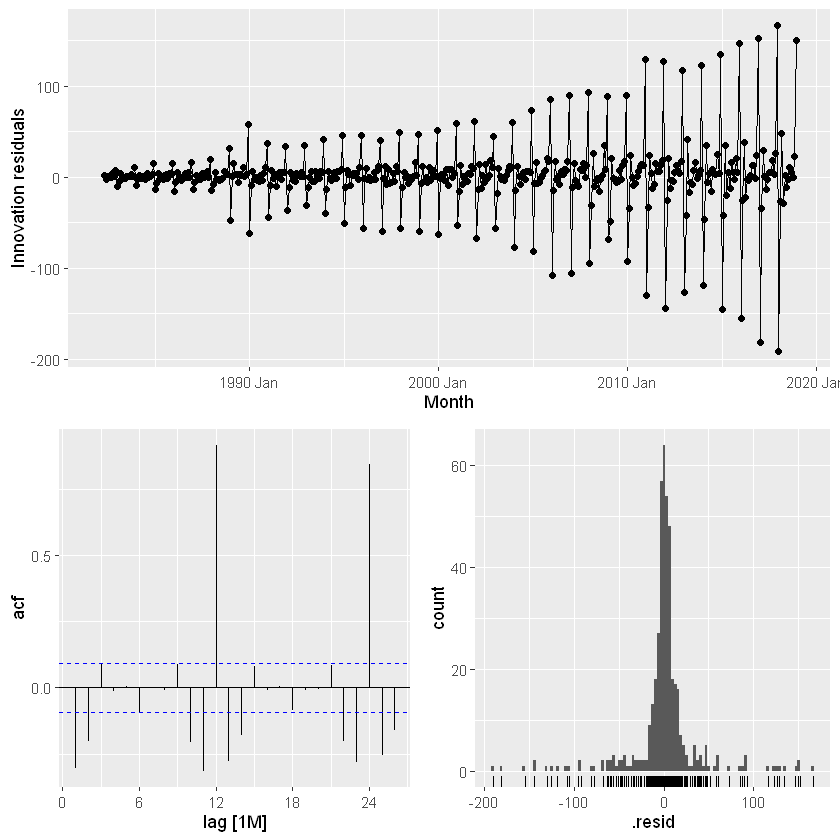

In [23]:
best_fit <- fit %>% select(Naive)

gg_tsresiduals(best_fit)

ljung_test <- augment(best_fit) %>%
  features(.resid, ljung_box, lag = 24, dof = 0)

ljung_test

Atlikta diagnostika rodo, kad geriausio (ETS) modelio liekanos nėra baltasis triukšmas. Tiek ACF grafike matomas reikšmingas išsišokimas ties 12 vėlavimu, tiek Ljung-Box testas ($p \approx 0$) patvirtina, kad modelis nepajėgė pilnai aprašyti metinio sezoniškumo. Tai reiškia, kad nors modelis geriausias iš tirtų, jis vis dar palieka neišnaudotos informacijos, todėl jo generuojami pasikliautinieji intervalai gali būti netikslūs.

3. Now use time-series cross-validation with a minimum sample size of 15 years, a step size of 1 year, and a forecast horizon of 5 years. Calculate the RMSE of the results. Does it change the conclusion you reach based on the test set?

In [24]:
cv_results <- retail %>%
  stretch_tsibble(.init = 15 * 12, .step = 12) %>%
  model(
    ETS    = ETS(Turnover),
    Mean   = MEAN(Turnover),
    Naive  = NAIVE(Turnover),
    SNaive = SNAIVE(Turnover)
  ) %>%
  forecast(h = 5 * 12) %>%
  accuracy(retail) %>%
  select(.model, RMSE, MAE, MAPE, MASE) %>%
  arrange(RMSE)

cv_results

.model,RMSE,MAE,MAPE,MASE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ETS,47.54524,30.18504,11.41505,2.293390
SNaive,57.64529,40.76161,15.91204,3.096975
Naive,70.97163,43.02877,15.57085,3.269228
Mean,165.60074,140.06838,52.82791,10.642077


Kryžminė patikra patvirtina ETS modelio lyderystę su ženkliai mažesne vidutine paklaida ($RMSE=47.55$) nei pandeminiu laikotarpiu. Svarbu tai, kad ilguoju laikotarpiu atsistatė logiška hierarchija: SNaive metodas aplenkė Naive. Tai įrodo, kad stabilioje rinkoje sezoniniai dėsningumai yra kritiniai, o anksčiau stebėtas Naive pranašumas buvo nulemtas specifinių 2019–2022 m. laikotarpio sukrėtimų.

4. Which of these two methods of evaluating accuracy is more reliable? Why?

Patikimesnis vertinimo metodas yra kryžminė patikra (Time-Series Cross-Validation). Pirmasis metodas rėmėsi tik viena, specifine atkarpa (2019–2022 m.), kurios rezultatus stipriai iškreipė pandeminis šokas. Tuo tarpu kryžminė patikra įvertina modelio stabilumą per daugelį skirtingų periodų, taip eliminuodama atsitiktinumus ir pateikdama objektyvesnį, o ne vienu istoriniu epizodu paremtą, tikslumo įvertinimą.